# Plot Bliss ablation results
Utility helpers to visualize per-subset RMSE for g/h regressors.

In [7]:
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd

BASE_DIR = Path("ablation_result")

# Light style tweaks
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.linestyle"] = "--"

In [8]:
def _find_result_file(job_name: str, model: str, tree_model: Optional[str] = None) -> Path:
    base = BASE_DIR / job_name / model
    if not base.exists():
        raise FileNotFoundError(f"No results directory at {base}")

    if tree_model:
        candidate = base / f"{tree_model}_ablation_results.csv"
        if not candidate.exists():
            raise FileNotFoundError(f"No CSV at {candidate}")
        return candidate

    csvs = sorted(base.glob("*_ablation_results.csv"))
    if not csvs:
        raise FileNotFoundError(f"No ablation CSVs under {base}")

    # Prefer xgboost if present
    for c in csvs:
        if "xgboost" in c.name:
            return c
    return csvs[0]


def load_ablation(job_name: str, model: str, tree_model: Optional[str] = None) -> pd.DataFrame:
    path = _find_result_file(job_name, model, tree_model)
    df = pd.read_csv(path)
    df = df.sort_values("mean_round_rmse").reset_index(drop=True)
    df["subset_label"] = df["subset_name"].apply(_pretty_label)
    return df, path


def _pretty_label(name: str) -> str:
    if name == "full":
        return "Full"
    label = name
    label = label.replace("full_minus_", "Full - ")
    label = label.replace("full_", "Full ")
    label = label.replace("_", " ")
    return label.capitalize()


def plot_ablation(job_name: str, tree_model: Optional[str] = None, top_n: Optional[int] = None) -> None:
    models = ["g", "h"]
    loaded = {}
    for m in models:
        try:
            loaded[m] = load_ablation(job_name, m, tree_model)
        except FileNotFoundError as e:
            print(f"{m}: {e}")

    if not loaded:
        print("No results found.")
        return

    # Height scales with the largest panel for readability
    max_rows = max(len(v[0]) if top_n is None else min(top_n, len(v[0])) for v in loaded.values())
    height = max(4, 0.35 * max_rows)

    fig, axes = plt.subplots(nrows=len(models), ncols=1, figsize=(11, height), sharex=True)
    if len(models) == 1:
        axes = [axes]

    for ax, m in zip(axes, models):
        if m not in loaded:
            ax.axis("off")
            continue
        df, path = loaded[m]
        data = df.head(top_n) if top_n else df
        y_pos = range(len(data))
        ax.barh(y_pos, data["mean_round_rmse"], color="#4C72B0")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(data["subset_label"])
        ax.invert_yaxis()
        title = f"{job_name} – {m} ({path.name})"
        ax.set_title(title)
        ax.set_xlabel("Mean per-round RMSE")

        # Annotate bars with values
        for y, v in zip(y_pos, data["mean_round_rmse"]):
            ax.text(v, y, f" {v:.4f}", va="center", ha="left", fontsize=8)

    plt.tight_layout()
    plt.show()

### Usage

Uncomment and edit `job_name` if you want to preview in this notebook.

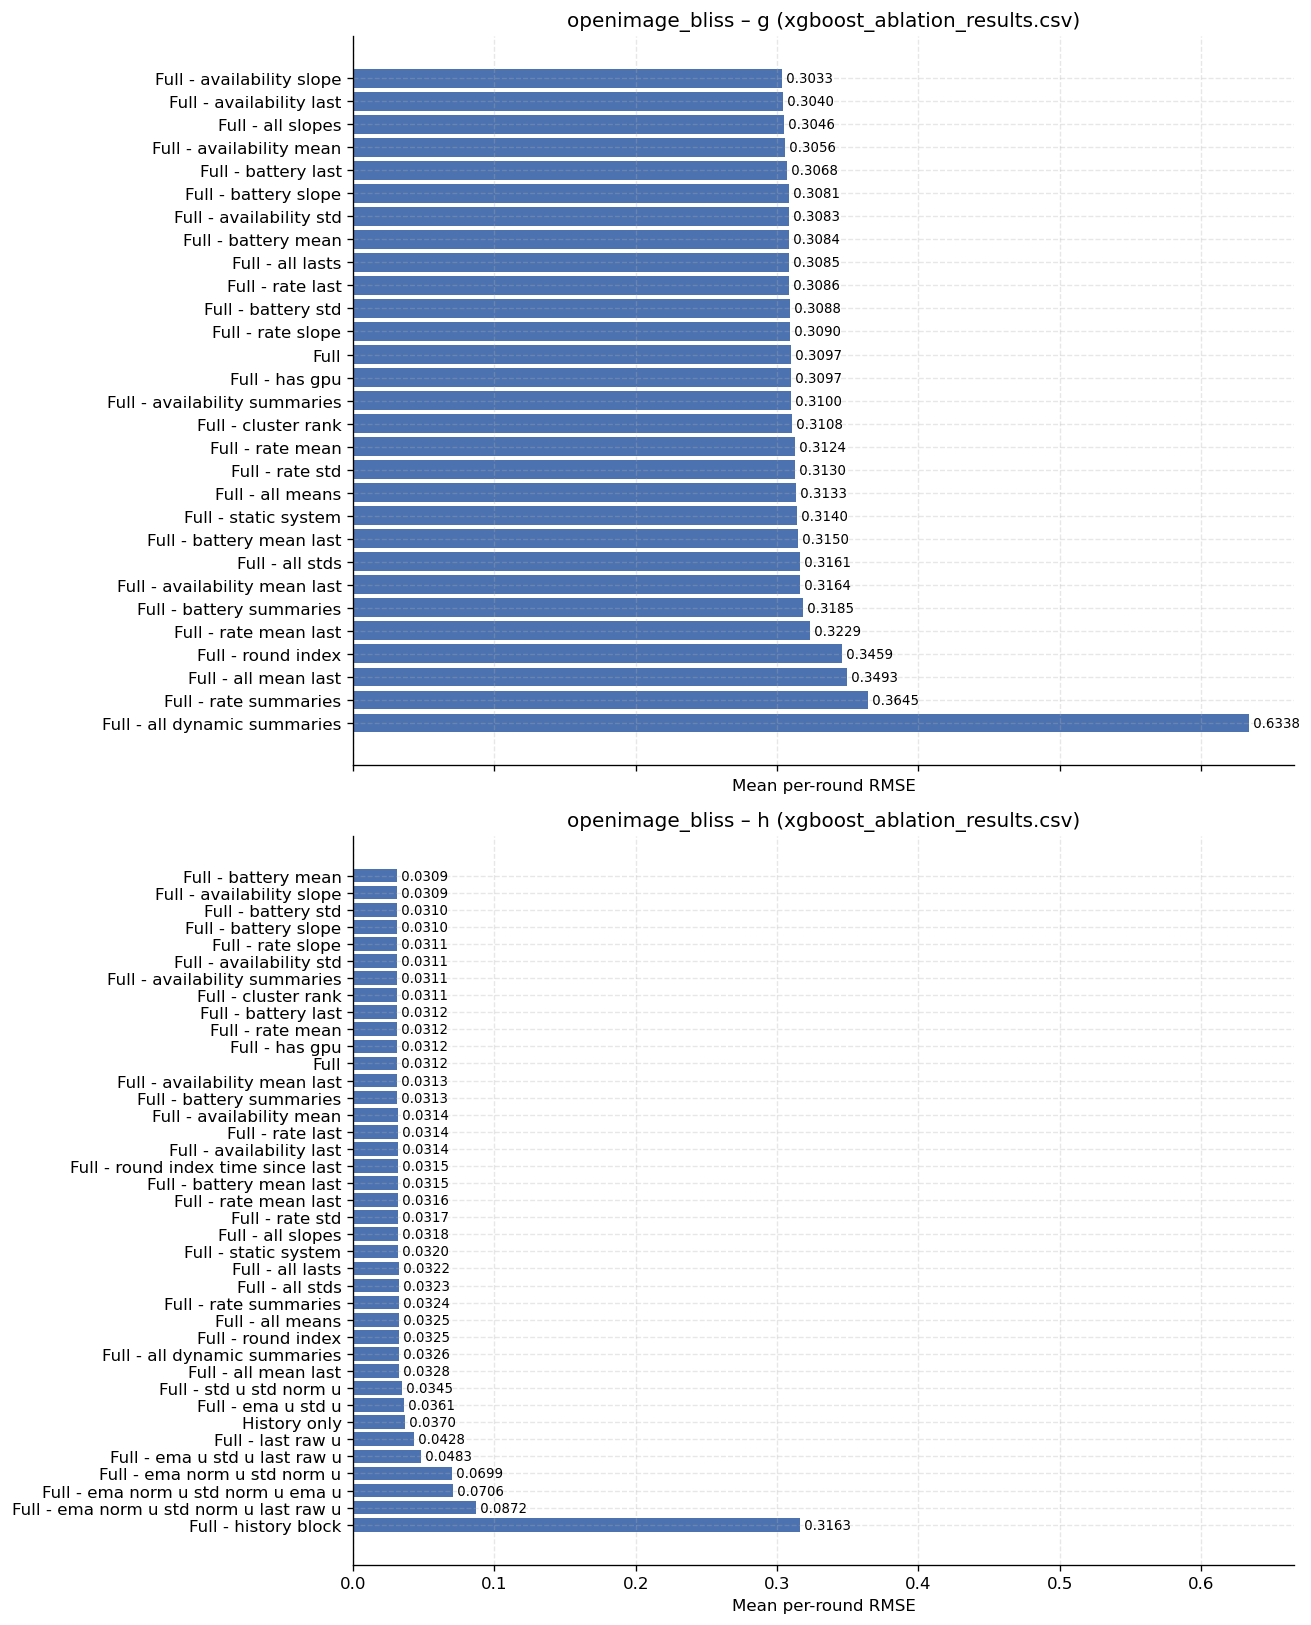

In [11]:
job_name = "openimage_bliss"
plot_ablation(job_name, tree_model="xgboost", top_n=50)